## Problem 1
### 1. Create a class for Markov Decision Processes (MDPs) that takes advantage of how you defined Markov Reward Processes

This solution can be found in src/finite_mdp.py

{'forward_1': (1, 0), 'left_1': (0, -1), 'right_1': (0, 1)}
[[-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20 100 100 100 100 100 -20]]
S size: 95
A: {'forward_1', 'left_1', 'right_1'}
terminal_states: {'exit', 'crash'}
Policy Iteration: 1
Policy Iteration: 2
Policy Iteration: 3
Policy Iteration: 4
Policy Iteration: 5
Policy Iteration: 6
Policy Iteration: 7
Policy Iteration: 8
Policy Iteration: 9
Policy Iteration: 10
Policy Iteration: 11
Policy Iterat

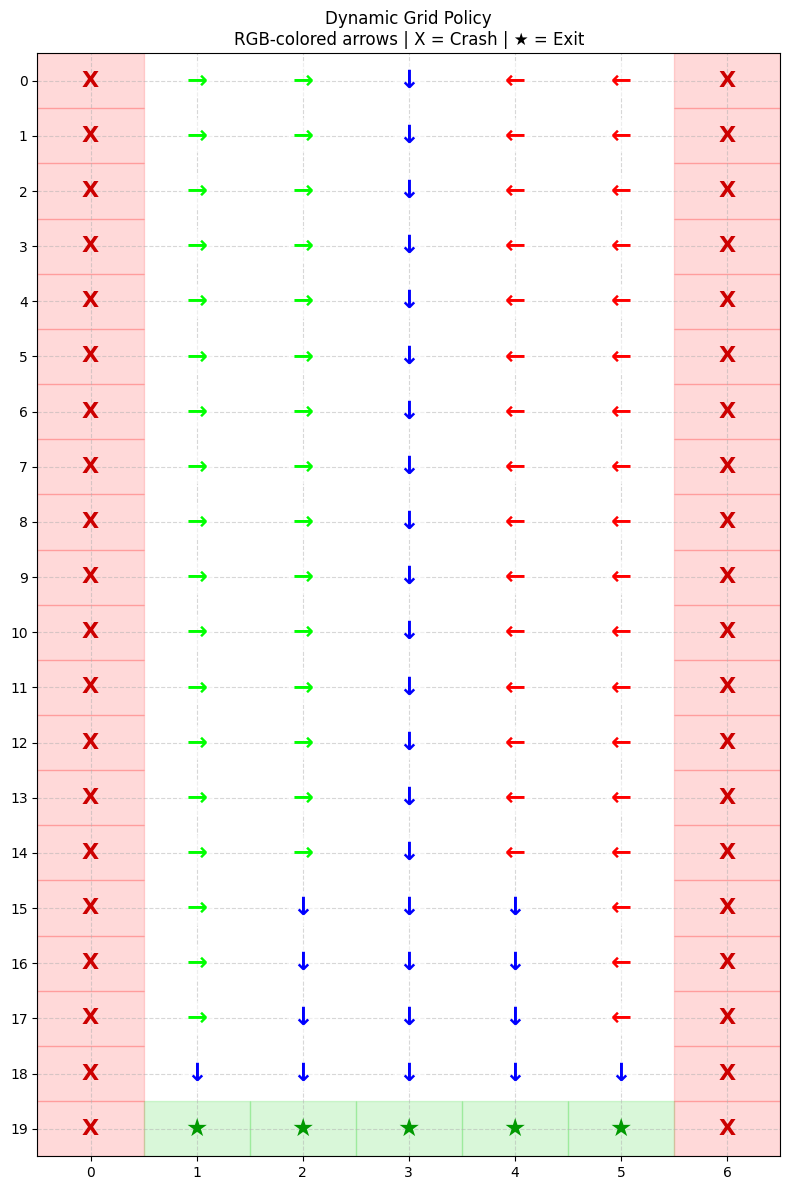

In [1]:
from src.p1.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
from src.p1.helpers import visualize_policy
from IPython.display import display
from src.utils.heatmap_animation import show_heatmap_animation_matplotlib

import os
# remove heatmap images
os.system("rm heatmaps/*.png")


# Set parameters for the grid world
grid_size = [20, 7]
reward_range = [-1, -1]
gamma = 0.99
step_penalty = -1
random_transition_type = "m2p1"
random_probability = 0.2 # wind chance
start_state = (0, 3)
range_of_motions = (grid_size[1] - 2) // 5
# action_map = {
#     "forward": (1, 0), 
#     "left": (0, -1), 
#     "right": (0, 1)
# }
action_map = {}

for i in range(range_of_motions):
    action_map["forward_" + str(i+1)] = (i+1, 0)
    action_map["left_" + str(i+1)] = (0, -i-1)
    action_map["right_" + str(i+1)] = (0, i+1)

print(action_map)

# Create the action map

# Create the terminal map
terminal_map = {
    "crash": -20,
    "exit": 100
}

# Generate the grid for the environment
grid = generate_grid(
    grid_size=grid_size,
    reward_range=reward_range,
    terminal_state_values=list(terminal_map.values())
)

print(grid)

# Initialize the environment
chasm_env = GridEnvironment(
    curr_grid=grid,
    terminal_map=terminal_map,
    action_map=action_map,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type=random_transition_type,
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    chasm_env,
)

# # Create the animation for the value convergence
# anim = show_heatmap_animation_matplotlib(
#     image_dir="heatmaps",
#     fps=6
# )

# display(anim)

# Print the optimal policy
print("\nOptimal policy:")
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()
print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

# Visualize the policy
visualize_policy(grid_size, policy, mask=grid)



[[   -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf]
 [   -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf]
 [-482.3     -inf    -inf    -inf    -inf    -inf    -inf    -inf    -inf]
 [-334.   -480.3  -480.3     -inf    -inf    -inf    -inf    -inf    -inf]
 [-144.93 -186.83 -332.   -478.3     -inf    -inf    -inf    -inf    -inf]
 [ -44.72  -70.   -142.93 -330.   -476.3     -inf    -inf    -inf    -inf]
 [  -9.53  -21.71  -68.   -140.93 -328.   -474.3     -inf    -inf    -inf]
 [  -2.19   -6.    -19.71  -66.   -138.93 -326.   -472.3     -inf    -inf]
 [ 100.    200.    200.    200.    200.    200.    200.    200.      -inf]
 [  -2.19   -6.    -19.71  -66.   -138.93 -326.   -472.3     -inf    -inf]
 [  -9.53  -21.71  -68.   -140.93 -328.   -474.3     -inf    -inf    -inf]
 [ -44.72  -70.   -142.93 -330.   -476.3     -inf    -inf    -inf    -inf]
 [-144.93 -186.83 -332.   -478.3     -inf    -inf    -inf    -inf    -inf]
 [-334.   -480.3  -480.3 

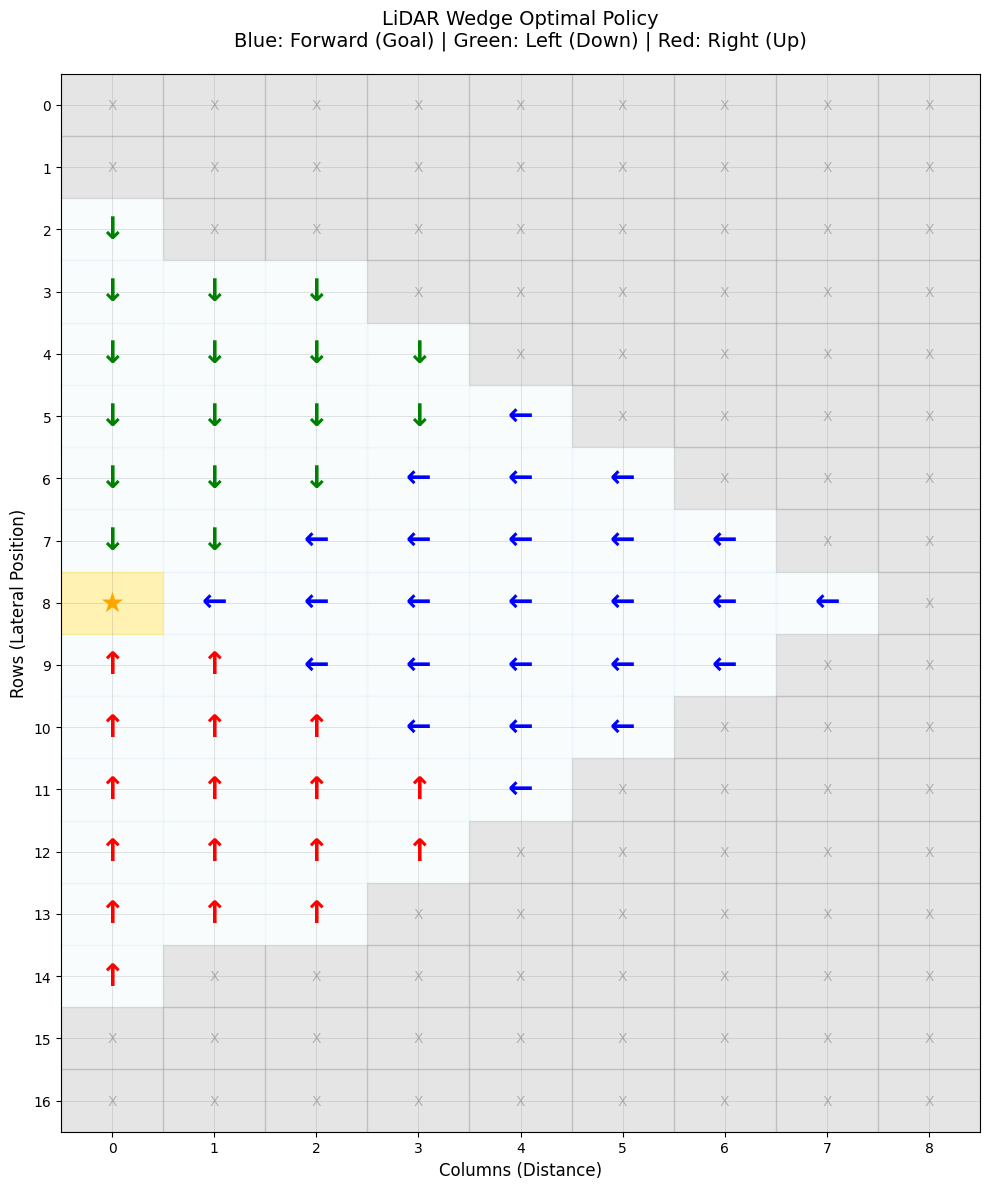

In [1]:
from src.p2.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
import numpy as np
from src.p2.helpers import visualize_lidar_policy

LiDAR_range = 8 # range of the LiDAR sensor in meters
grid_size = [(LiDAR_range * 2) + 1, LiDAR_range + 1]
slice_angle = 80 # angle of the LiDAR sensor in degrees
# Create the terminal map
terminal_map = {
    "goal": 100,
    "crash": -10
}

grid = generate_grid(
    grid_size=grid_size,
    terminal_state_values=list(terminal_map.values()),
    slice_angle=slice_angle
)
print(grid)

action_map = {
    "forward": (0, -1), 
    "left": (1, 0), 
    "right": (-1, 0)
}

gamma = 0.99
step_penalty = -1
random_probability = 0.15
start_state = (0, 0)

lidar_env = GridEnvironment(
    curr_grid=grid,
    terminal_map=terminal_map,
    action_map=action_map,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type="m2p2",
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    lidar_env,
)

# # Create the animation for the value convergence
# anim = show_heatmap_animation_matplotlib(
#     image_dir="heatmaps",
#     fps=6
# )

# display(anim)

# Print the optimal policy
print("\nOptimal policy:")
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()
print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

visualize_lidar_policy(grid, policy, grid_size)
